In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
import os
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

In [9]:
data_directory = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/DHM/Test2/Week2/ts_From_Fluo_mask/test"
output_dir = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/DHM/Test2/Week2/ts_From_Fluo_mask_GF_Avg_Sub_Outliers/test"
os.makedirs(output_dir, exist_ok= True)

In [10]:

n_npz = sum(
    1 for f in os.listdir(data_directory)
    if f.lower().endswith(".npz") and os.path.isfile(os.path.join(data_directory, f))
)

print("Number of .npz files:", n_npz)

Number of .npz files: 1


Test2_Week_2_2022_09_01_10_51_35_Rec_BS_WithHolRef_Phase_SZ17228_ts_labels: shape=(257, 841), global_min=-0.04506, global_mean=1.413


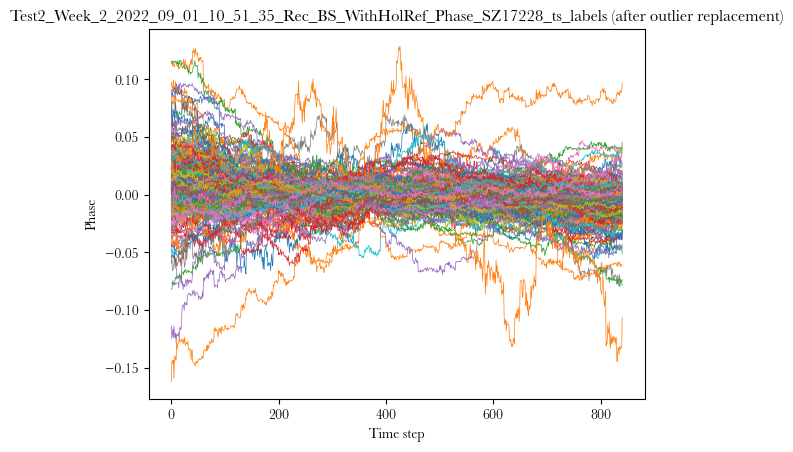

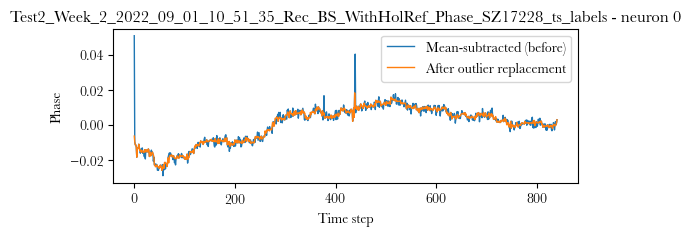

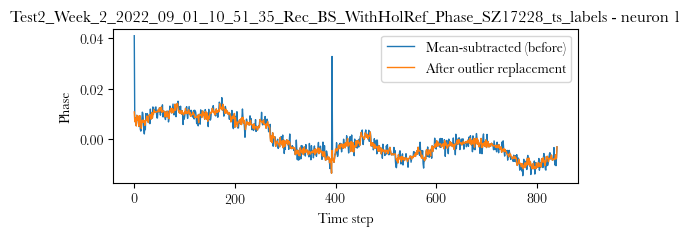

Saved: /Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/DHM/Test2/Week2/ts_From_Fluo_mask_GF_Avg_Sub_Outliers/test/Test2_Week_2_2022_09_01_10_51_35_Rec_BS_WithHolRef_Phase_SZ17228_ts_labels_AvgSub_OutlierSub.npz -> (257, 841)


In [11]:

# Function to reject outliers in chunks of 10 steps and replace them with the mean value
def reject_outliers(data, chunk_size=10, m=1):
    filtered_data = np.copy(data)
    for start in range(0, len(data), chunk_size):
        end = min(start + chunk_size, len(data))
        chunk = data[start:end]
        mean = np.mean(chunk)
        std_dev = np.std(chunk)
        filtered_chunk = np.where(abs(chunk - mean) < m * std_dev, chunk, mean)
        filtered_data[start:end] = filtered_chunk
    return filtered_data

# assumes reject_outliers(...) already exists

def process_ts_file(ts_path, output_dir, chunk_size=10, m=1, do_plots=False, crop_T=None):
    base_name = os.path.splitext(os.path.basename(ts_path))[0]

    z = np.load(ts_path, allow_pickle=True)   # NPZ
    if "ts" not in z.files:
        print(f"Skipping {base_name}: no 'ts' key. keys={z.files}")
        z.close()
        return

    Ts_loaded = z["ts"]                       # original (N, T)
    Ts = Ts_loaded.astype(np.float32, copy=True)

    print(f"{base_name}: shape={Ts.shape}, global_min={Ts.min():.4g}, global_mean={Ts.mean():.4g}")

    # 1) subtract per-neuron mean
    Ts -= Ts.mean(axis=1, keepdims=True)

    # 2) outlier replacement
    filtered_Ts = np.empty_like(Ts)
    for i in range(Ts.shape[0]):
        filtered_Ts[i] = reject_outliers(Ts[i], chunk_size=chunk_size, m=m)

    # optional crop
    final_Ts = filtered_Ts[:, :crop_T] if crop_T is not None else filtered_Ts
    Ts_plot  = Ts[:, :crop_T] if crop_T is not None else Ts  # for comparison plots

    if do_plots:
        plt.figure()
        plt.plot(final_Ts.T, linewidth=0.5)
        plt.title(f"{base_name} (after outlier replacement)")
        plt.xlabel("Time step")
        plt.ylabel("Phase")
        plt.show()

        for i in range(min(2, Ts.shape[0])):
            plt.figure(figsize=(6, 2))
            plt.plot(Ts_plot[i], linewidth=1.0, label="Mean-subtracted (before)")
            plt.plot(final_Ts[i], linewidth=1.0, label="After outlier replacement")
            plt.legend()
            plt.title(f"{base_name} - neuron {i}")
            plt.xlabel("Time step")
            plt.ylabel("Phase")
            plt.show()

    # ---- save NPZ with same structure (all original keys preserved), only ts replaced ----
    os.makedirs(output_dir, exist_ok=True)

    out_dict = {k: z[k] for k in z.files}
    out_dict["ts"] = final_Ts.astype(np.float32)

    z.close()

    out_path = os.path.join(output_dir, base_name + "_AvgSub_OutlierSub.npz")
    np.savez(out_path, **out_dict)

    # ---- check same shape structure saved (keys + shapes) ----
    z_out = np.load(out_path, allow_pickle=True)
    assert set(z_out.files) == set(out_dict.keys()), "Output keys differ from input keys!"
    assert z_out["ts"].shape == final_Ts.shape, f"ts shape mismatch: {z_out['ts'].shape} vs {final_Ts.shape}"
    z_out.close()

    print("Saved:", out_path, "->", final_Ts.shape)


# run (NPZ)
for file in os.listdir(data_directory):
    if file.lower().endswith(".npz"):
        process_ts_file(
            os.path.join(data_directory, file),
            output_dir,
            chunk_size=10,
            m=1,
            do_plots=True,
            crop_T=None
        )